In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import arviz as az
import ast

import h5py
import glob

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import ringdown as rd

In [3]:
# nr_path = glob.glob(str(dirs.simdir / args.sim / 'SXS_BBH_*.h5'))[0]
# get true remnant values
mtot = 72
with h5py.File('/mnt/home/nkhusid/spec_inj/data/sxs_sims/SXS_BBH_1155/SXS_BBH_1155_Res3.h5', 'r') as f:
    Mflower = f.attrs['f_lower_at_1MSUN']
    mf_true = f['remnant-mass-vs-time']['Y'][-1]
    cfx = f['remnant-spinx-vs-time']['Y'][-1]
    cfy = f['remnant-spiny-vs-time']['Y'][-1]
    cfs = f['remnant-spinz-vs-time']['Y'][-1]
    cf_true = np.linalg.norm([cfx, cfy, cfs])
mf_true *= mtot
f_start = Mflower/mtot
print(f'Starting frequency: {f_start} Hz')
TM = mf_true*rd.qnms.T_MSUN
print(mf_true, cf_true)

Starting frequency: 9.030048091247401 Hz
68.51542214085012 0.6864399767023986


In [4]:
fit_peak = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/220+210_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined_miness300/engine/1126259462.423000/config.ini')
# res_light = rd.Result.from_netcdf('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot72/220+210_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_edgeon/engine/1126259462.423000/result.nc')
res_heavy = rd.Result.from_netcdf('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/220+210_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_inclined_miness300/engine/1126259462.423000/result.nc')

In [5]:
fit_light = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1155/mtot72/220+210_SXS_BBH_1155_fmin10Hz_ppSNR20_mtot72_faceon/engine/1126259462.423000/config.ini')
fit_heavy = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1155/mtot330/220+210_SXS_BBH_1155_fmin10Hz_ppSNR20_mtot330_faceon/engine/1126259462.423000/config.ini')

In [15]:
fit_light_p = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot72/linesub/220+210_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot72_faceon/engine/1126259462.423000/config.ini')
fit_heavy_p = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/linesub/220+210_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_faceon/engine/1126259462.423000/config.ini')

In [6]:
fit_light_e = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1155/mtot72/220+210_SXS_BBH_1155_fmin10Hz_ppSNR20_mtot72_faceon/engine/1126259462.418950/config.ini')
fit_heavy_e = rd.Fit.from_config('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1155/mtot330/220+210_SXS_BBH_1155_fmin10Hz_ppSNR20_mtot330_faceon/engine/1126259462.404439/config.ini')

In [13]:
fit_light.start_times, fit_heavy.start_times

({'H1': 1126259462.437694, 'L1': 1126259462.4307084},
 {'H1': 1126259462.437694, 'L1': 1126259462.4307084})

In [20]:
config_light = ast.literal_eval(fit_light.attrs['config'])
config_heavy = ast.literal_eval(fit_heavy.attrs['config'])

In [23]:
float(config_heavy['model']['m_min'])

157.01450907

(1126259462.1283448, 1126259462.7470434)

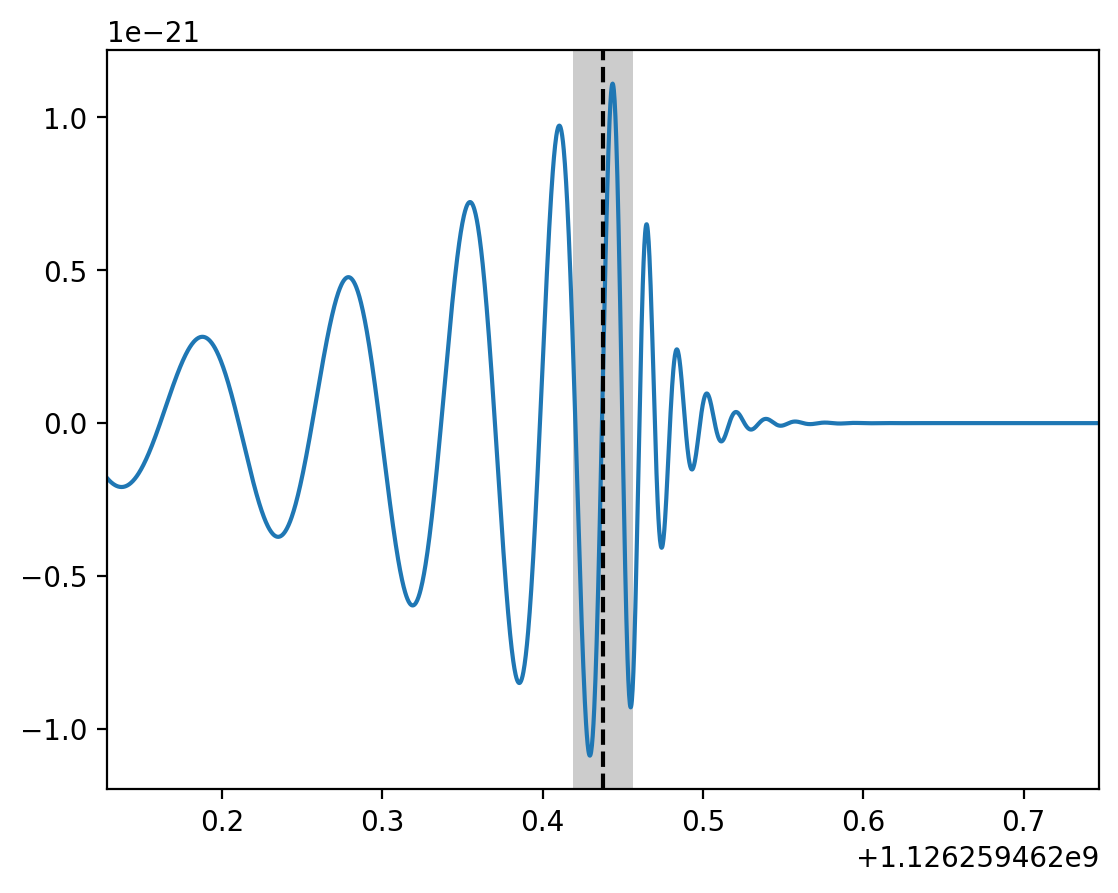

In [32]:
plt.plot(fit_heavy.data['H1'])
peak = fit_heavy.start_times['H1']
plt.axvline(peak, c='k', ls='--')
TM = rd.qnms.T_MSUN * float(config_heavy['model']['m_min']) * 2
plt.axvspan(peak-12*TM, peak+12*TM, color='k', lw=0, alpha=0.2)
plt.xlim(peak-200*TM, peak+200*TM)

(1126259462.1283448, 1126259462.7470434)

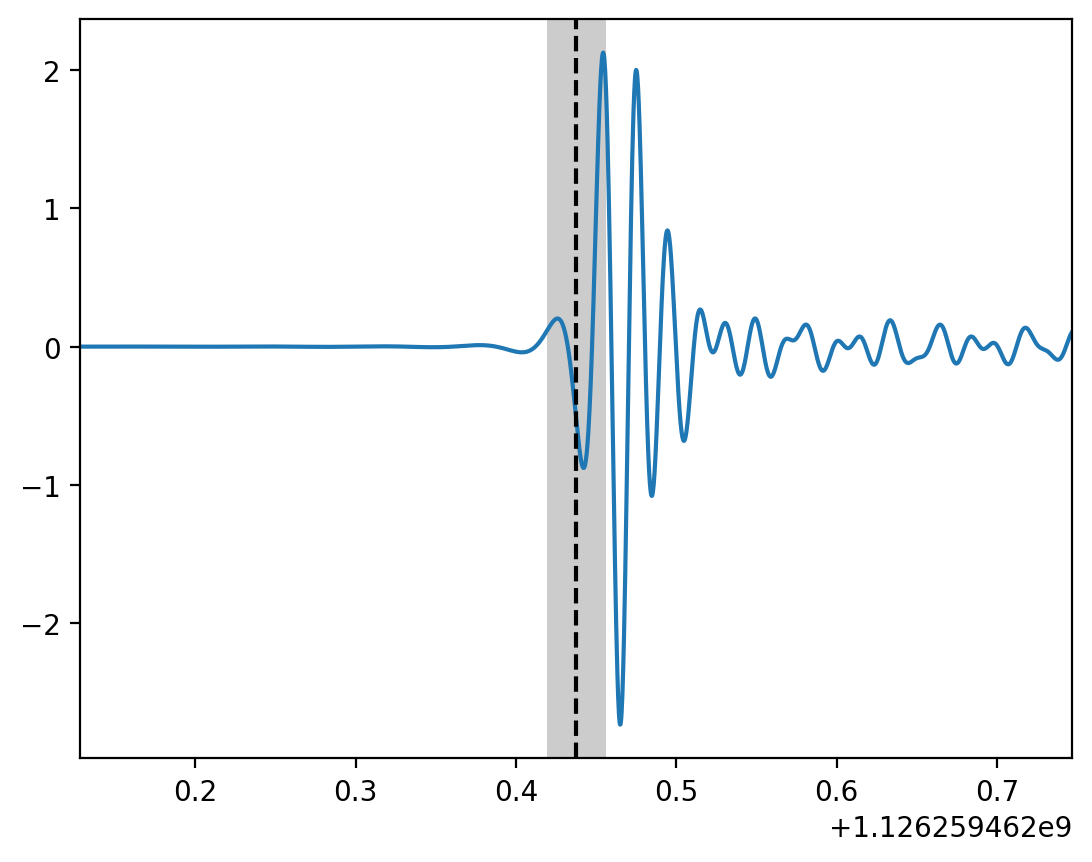

In [ ]:
wd = fit_heavy.whiten(fit_heavy.data)
plt.plot(wd['H1'])
peak = fit_heavy.start_times['H1']
plt.axvline(peak, c='k', ls='--')
TM = rd.qnms.T_MSUN * float(config_heavy['model']['m_min']) * 2
plt.axvspan(peak-12*TM, peak+12*TM, color='k', lw=0, alpha=0.2)
plt.xlim(peak-200*TM, peak+200*TM)

(1126259462.4191332, 1126259462.573808)

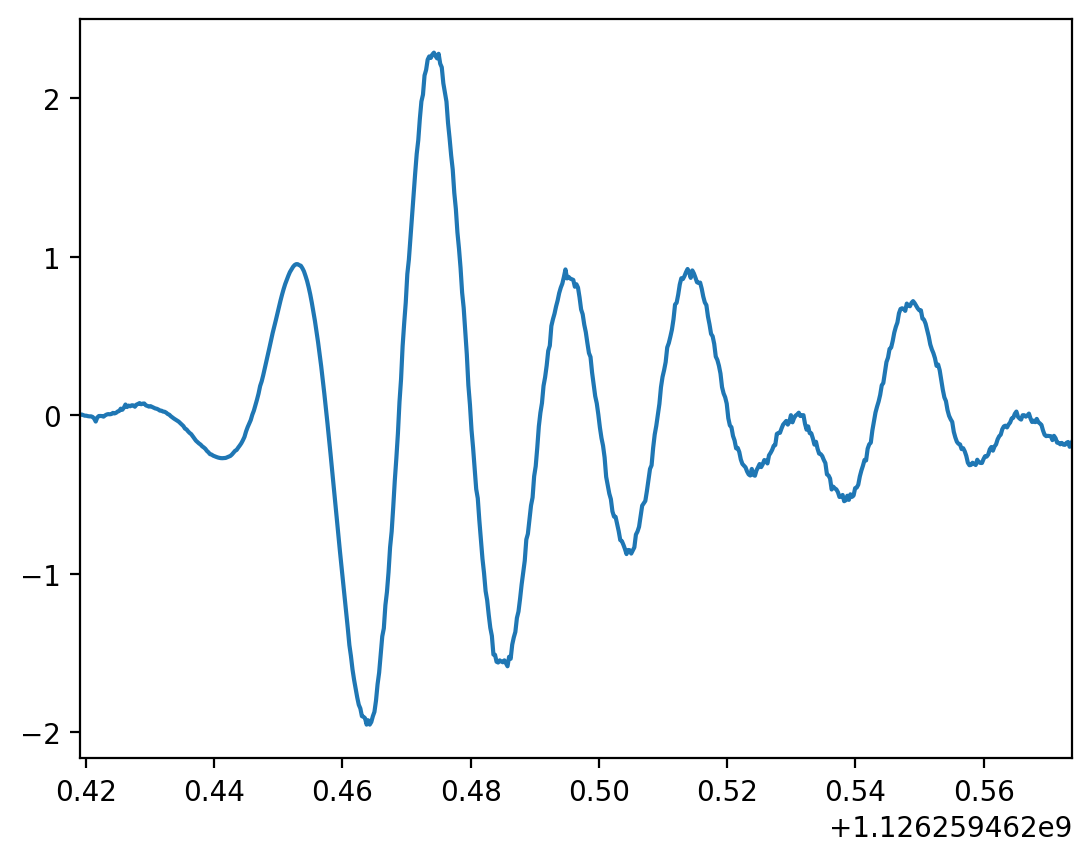

In [46]:
wd = fit_heavy_e.whiten(fit_heavy_e.analysis_data)
plt.plot(wd['H1'])
start = fit_heavy_e.start_times['H1']
# plt.axvline(start, c='k', ls='--')
TM = rd.qnms.T_MSUN * float(config_heavy['model']['m_min']) * 2
# plt.axvspan(start-12*TM, start+12*TM, color='k', lw=0, alpha=0.2)
plt.xlim(start, start+100*TM)

(1126259462.3701997, 1126259462.5051885)

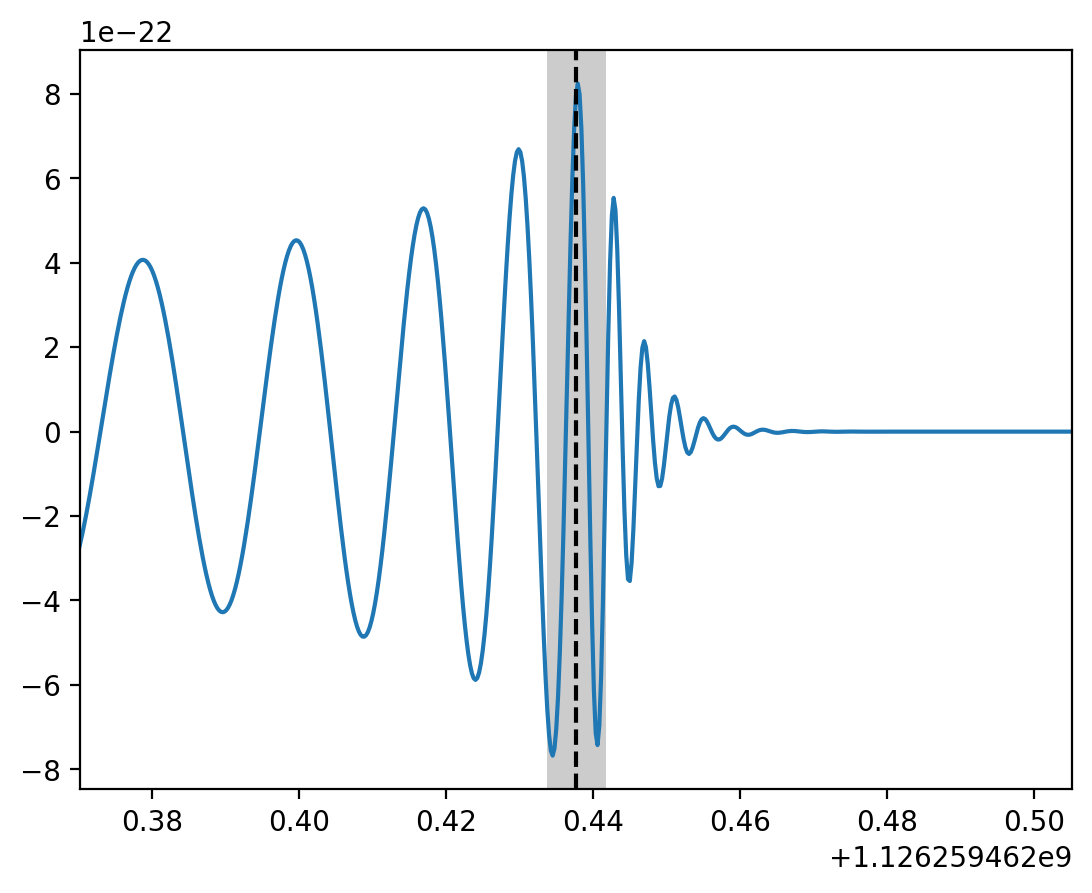

In [33]:
plt.plot(fit_light.data['H1'])
peak = fit_light.start_times['H1']
plt.axvline(peak, c='k', ls='--')
TM = rd.qnms.T_MSUN * float(config_light['model']['m_min']) * 2
plt.axvspan(peak-12*TM, peak+12*TM, color='k', lw=0, alpha=0.2)
plt.xlim(peak-200*TM, peak+200*TM)

(1126259462.3701997, 1126259462.5051885)

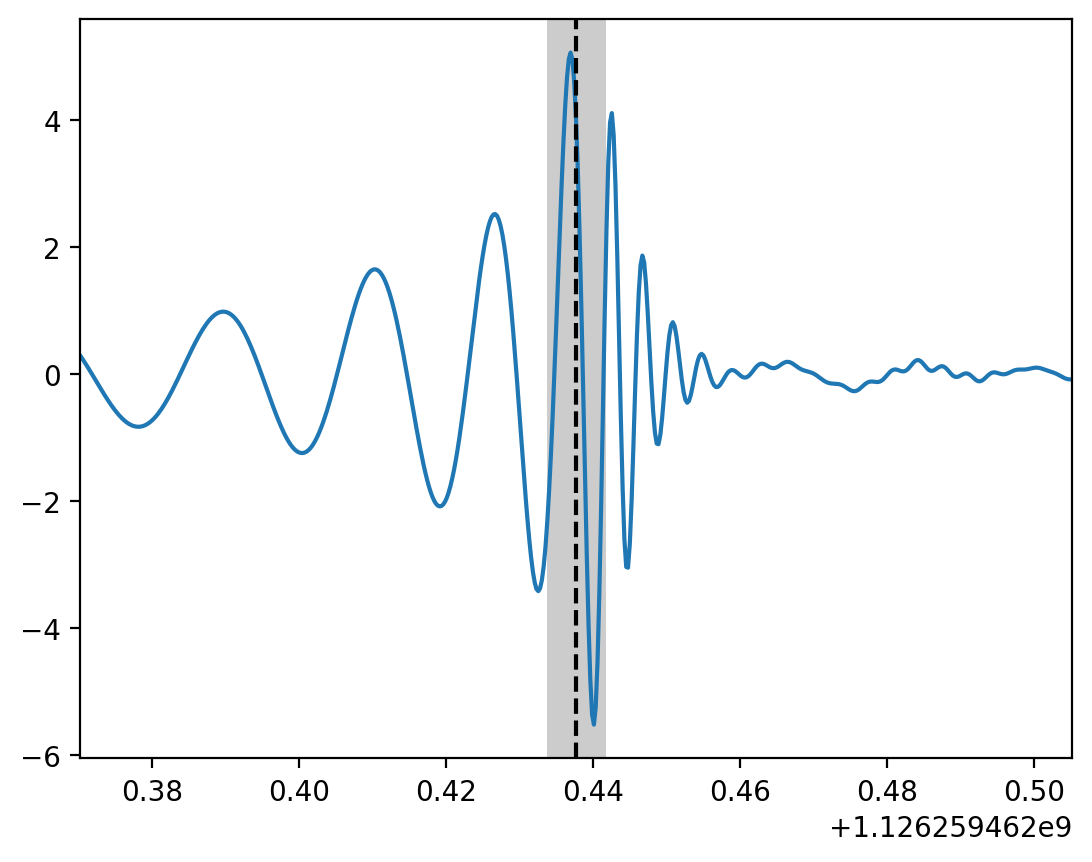

In [ ]:
wd = fit_light.whiten(fit_light.data)
plt.plot(wd['H1'])
peak = fit_light.start_times['H1']
plt.axvline(peak, c='k', ls='--')
TM = rd.qnms.T_MSUN * float(config_light['model']['m_min']) * 2
plt.axvspan(peak-12*TM, peak+12*TM, color='k', lw=0, alpha=0.2)
plt.xlim(peak-200*TM, peak+200*TM)

(1126259462.4336443, 1126259462.4673915)

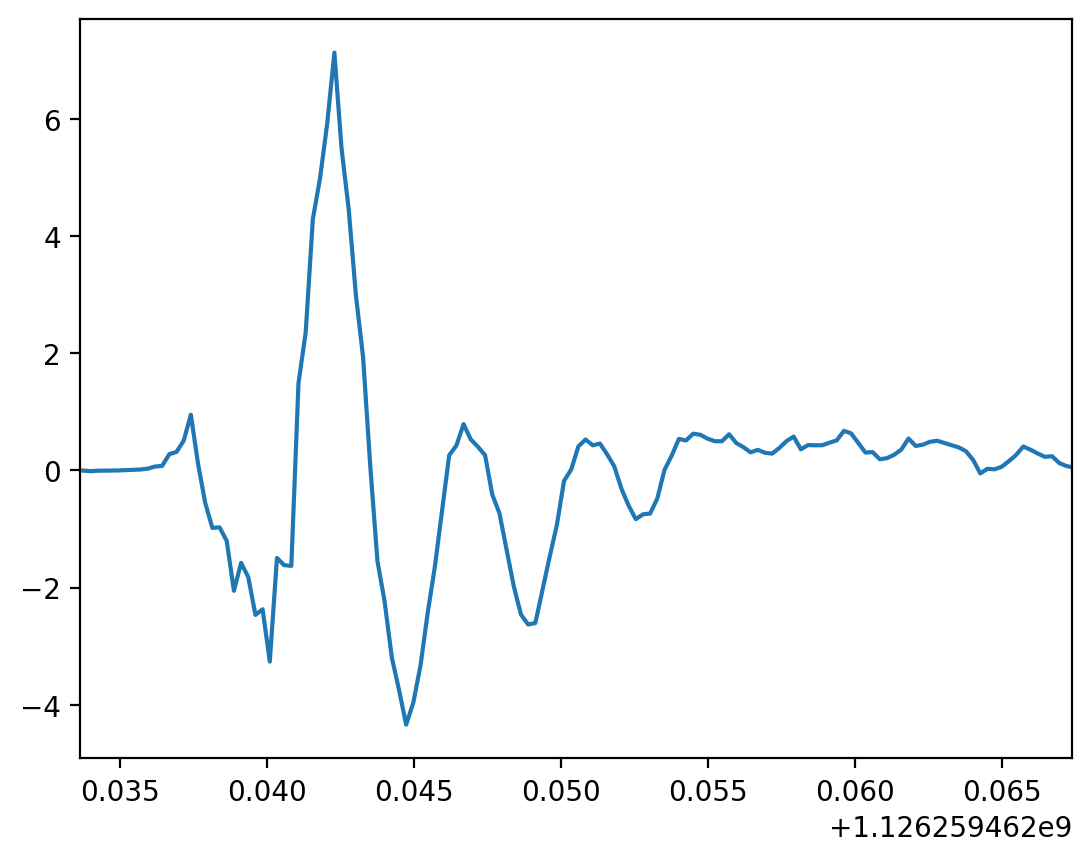

In [45]:
wd = fit_light_e.whiten(fit_light_e.analysis_data)
plt.plot(wd['H1'])
start = fit_light_e.start_times['H1']
# plt.axvline(start, c='k', ls='--')
TM = rd.qnms.T_MSUN * float(config_light['model']['m_min']) * 2
# plt.axvspan(start-12*TM, start+12*TM, color='k', lw=0, alpha=0.2)
plt.xlim(start, start+100*TM)

1126259462.4337423
1126259462.4190938


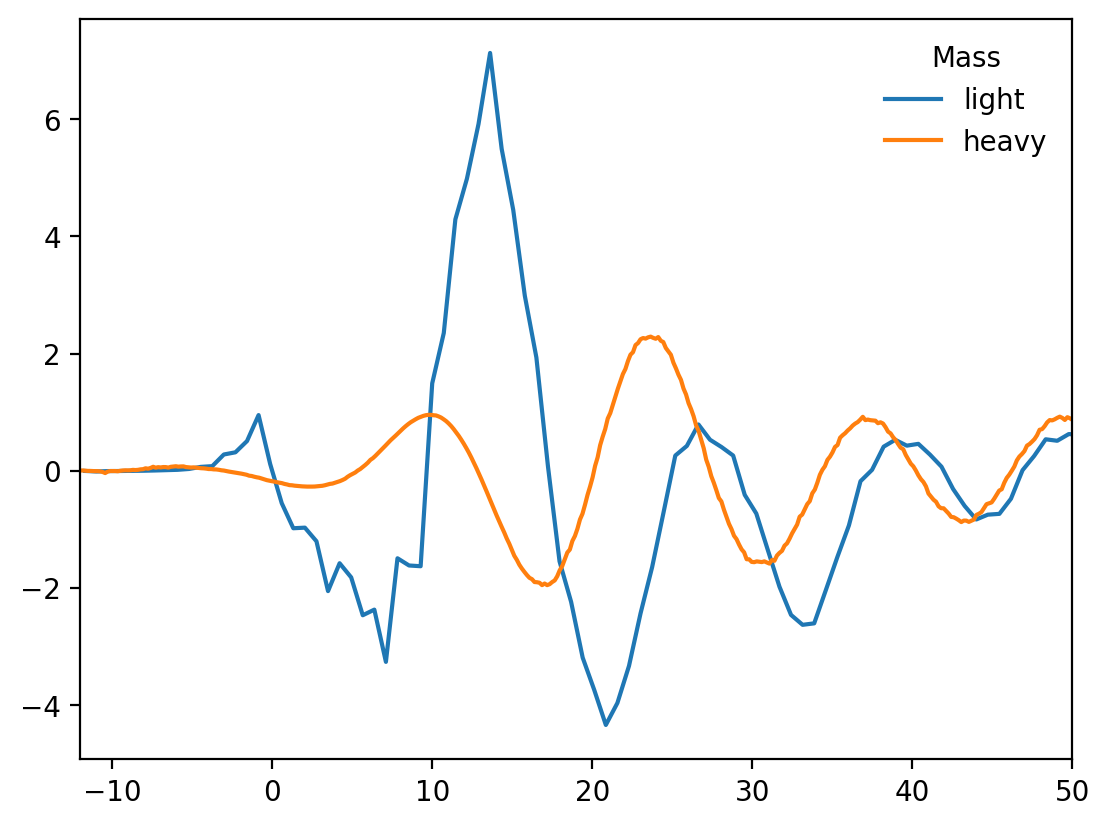

In [21]:
for fit, label in zip([fit_light_e, fit_heavy_e], ['light', 'heavy']):

    config = ast.literal_eval(fit.attrs['config'])
    TM = rd.qnms.T_MSUN * float(config['model']['m_min']) * 2

    wd = fit.whiten(fit.analysis_data)
    print(wd['H1'].time.values[0])
    l, = plt.plot((wd['H1'].time.values - fit_peak.start_times['H1']) / TM, wd['H1'].values, label=label)
    # start = fit.start_times['H1']
    # # plt.axvline(start, c='k', ls='--')
    
    # # plt.axvspan(start-12*TM, start+12*TM, color='k', lw=0, alpha=0.2)
plt.xlim(-12, 50)
plt.legend(title='Mass', frameon=False)

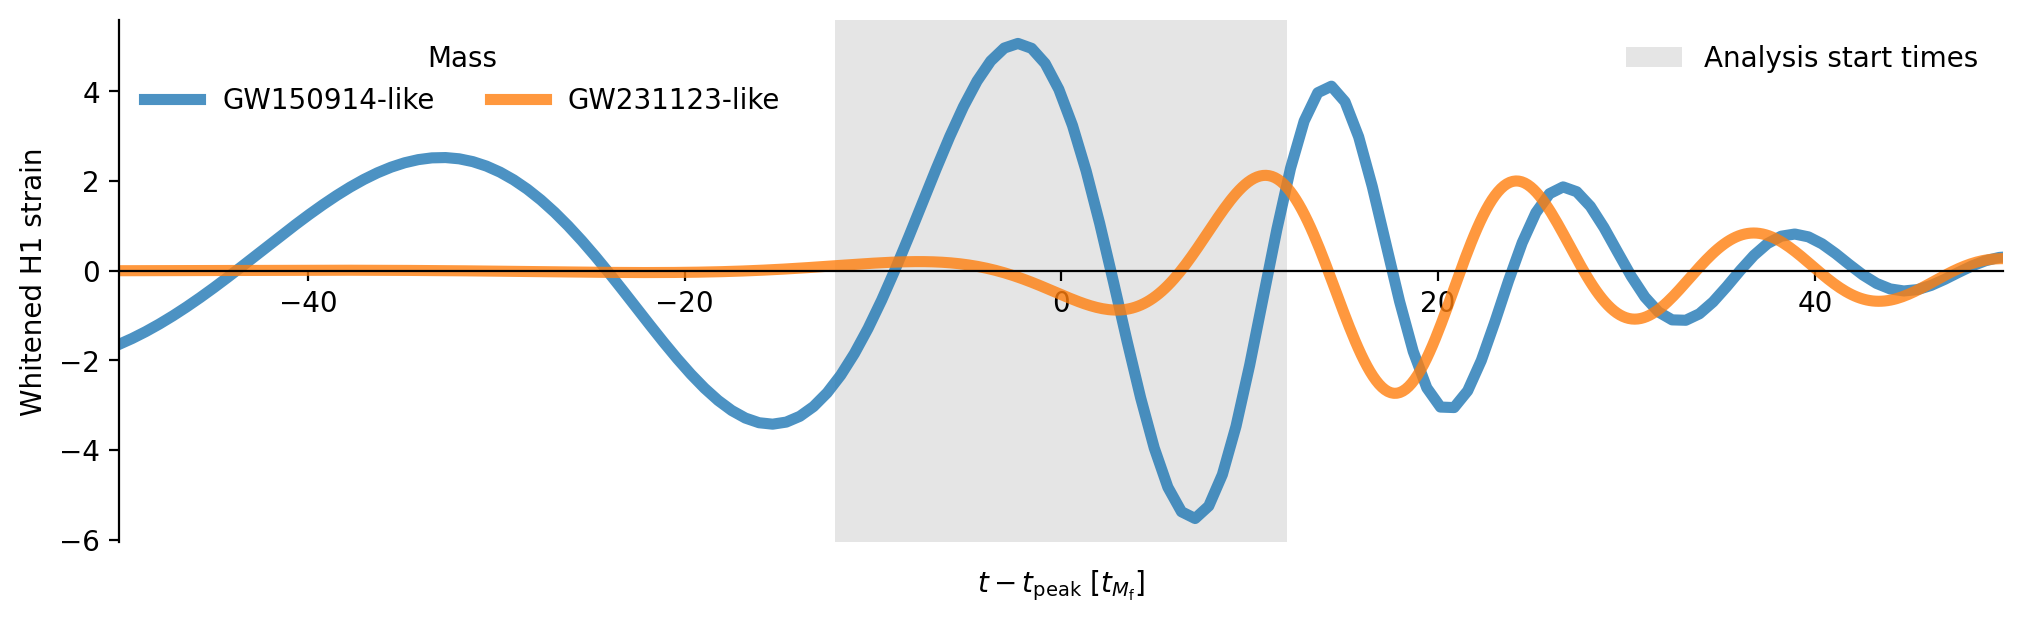

In [18]:
fig, ax = plt.subplots(figsize=(10, 3), layout='constrained')

for fit, label in zip([fit_light, fit_heavy], ['GW150914-like', 'GW231123-like']):

    config = ast.literal_eval(fit.attrs['config'])
    TM = rd.qnms.T_MSUN * float(config['model']['m_min']) * 2

    wd = fit.whiten(fit.data)
    # print(wd['H1'].time.values[0])
    l, = ax.plot((wd['H1'].time.values - fit_peak.start_times['H1']) / TM, wd['H1'].values, lw=4, alpha=0.8, label=label)
    # start = fit.start_times['H1']
    # # plt.axvline(start, c='k', ls='--')
    
    # # plt.axvspan(start-12*TM, start+12*TM, color='k', lw=0, alpha=0.2)
leg1 = ax.legend(title='Mass', frameon=False, ncol=2)
ax.add_artist(leg1)

# ax.axvline(0, c='k', ls=':')
v = ax.axvspan(-12, 12, color='k', alpha=0.1, lw=0, label='Analysis start times')
leg2 = ax.legend(handles=[v], frameon=False, loc='upper right')

ax.set_xlim(-50, 50)

ax.set_xlabel('$t - t_{\mathrm{peak}}$ $[t_{M_{\mathrm{f}}}]$')
ax.xaxis.set_label_coords(0.5, -0.05, transform=ax.transAxes)
ax.set_ylabel('Whitened H1 strain')

l.axes.spines['bottom'].set_position(('data', 0))
l.axes.spines['top'].set_visible(False)
l.axes.spines['right'].set_visible(False)

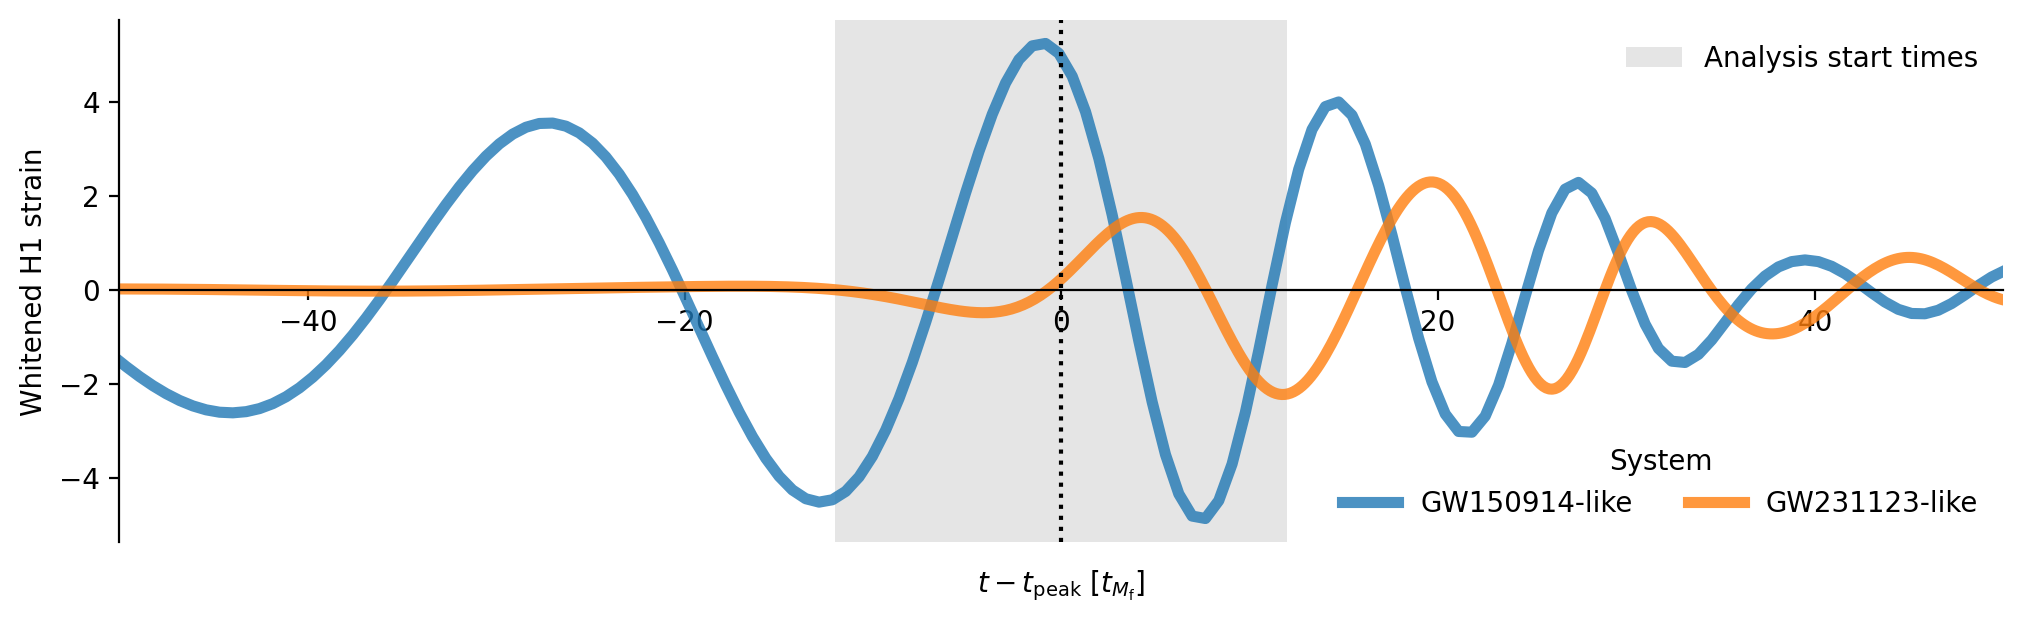

In [16]:
fig, ax = plt.subplots(figsize=(10, 3), layout='constrained')

for fit, label in zip([fit_light_p, fit_heavy_p], ['GW150914-like', 'GW231123-like']):

    config = ast.literal_eval(fit.attrs['config'])
    TM = rd.qnms.T_MSUN * float(config['model']['m_min']) * 2

    wd = fit.whiten(fit.data)
    # print(wd['H1'].time.values[0])
    l, = ax.plot((wd['H1'].time.values - fit_peak.start_times['H1']) / TM, wd['H1'].values, lw=4, alpha=0.8, label=label)
    # start = fit.start_times['H1']
    # # plt.axvline(start, c='k', ls='--')
    
    # # plt.axvspan(start-12*TM, start+12*TM, color='k', lw=0, alpha=0.2)
leg1 = ax.legend(title='System', frameon=False, ncol=2)
ax.add_artist(leg1)

ax.axvline(0, c='k', ls=':')
v = ax.axvspan(-12, 12, color='k', alpha=0.1, lw=0, label='Analysis start times')
leg2 = ax.legend(handles=[v], frameon=False, loc='upper right')

ax.set_xlim(-50, 50)

ax.set_xlabel('$t - t_{\mathrm{peak}}$ $[t_{M_{\mathrm{f}}}]$')
ax.xaxis.set_label_coords(0.5, -0.05, transform=ax.transAxes)
ax.set_ylabel('Whitened H1 strain')

l.axes.spines['bottom'].set_position(('data', 0))
l.axes.spines['top'].set_visible(False)
l.axes.spines['right'].set_visible(False)

In [53]:
fit_peak.start_times

{'H1': 1126259462.437694, 'L1': 1126259462.4307084}

In [6]:
light_inj = glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155_l2m2/mtot72/*_H1.hdf5')
heavy_inj = glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155_l2m2/mtot330/*_H1.hdf5')

In [7]:
light_inj_all = [f for f in glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155/mtot72/*_H1.hdf5') if 'ringup' not in f]
heavy_inj_all = [f for f in glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155/mtot330/*_H1.hdf5') if 'ringup' not in f]

In [8]:
light_fit_all = [f for f in glob.glob('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot72/linesub/220_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot72_*/engine/1126259462.418950/config.ini') if 'ringup' not in f]
heavy_fit_all = [f for f in glob.glob('/mnt/home/nkhusid/ceph/spec_inj/SXS_BBH_1156/mtot330/linesub/220_SXS_BBH_1156_fmin10Hz_ppSNR20_mtot330_*/engine/1126259462.404439/config.ini') if 'ringup' not in f]

In [9]:
light_inj_all

['/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155/mtot72/SXS_BBH_1155_fmin10Hz_ppSNR20_mtot72_edgeon_H1.hdf5',
 '/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155/mtot72/SXS_BBH_1155_fmin10Hz_ppSNR20_mtot72_inclined_H1.hdf5',
 '/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1155/mtot72/SXS_BBH_1155_fmin10Hz_ppSNR20_mtot72_faceon_H1.hdf5']

In [10]:
heavy_inj_p = glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1156_l2m2/mtot330/*_H1.hdf5')

In [11]:
light_inj_p_all = glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1156/mtot72/linesub/*_H1.hdf5')
heavy_inj_p_all = glob.glob('/mnt/home/nkhusid/spec_inj/data/injections/SXS_BBH_1156/mtot330/linesub/*_H1.hdf5')

In [12]:
light_dfs = {inj.split('_')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(light_inj)}

heavy_dfs = {inj.split('_')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(heavy_inj)}

In [13]:
light_dfs_all = {inj.split('_')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(light_inj_all)}

heavy_dfs_all = {inj.split('_')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(heavy_inj_all)}

In [14]:
light_ana_all = {file.split('/')[-4].split('_')[-1]: rd.Fit.from_config(file) for file in sorted(light_fit_all)}

heavy_ana_all = {file.split('/')[-4].split('_')[-1]: rd.Fit.from_config(file) for file in sorted(heavy_fit_all)}

In [15]:
light_ana_all

{}

(0.5, 2048)

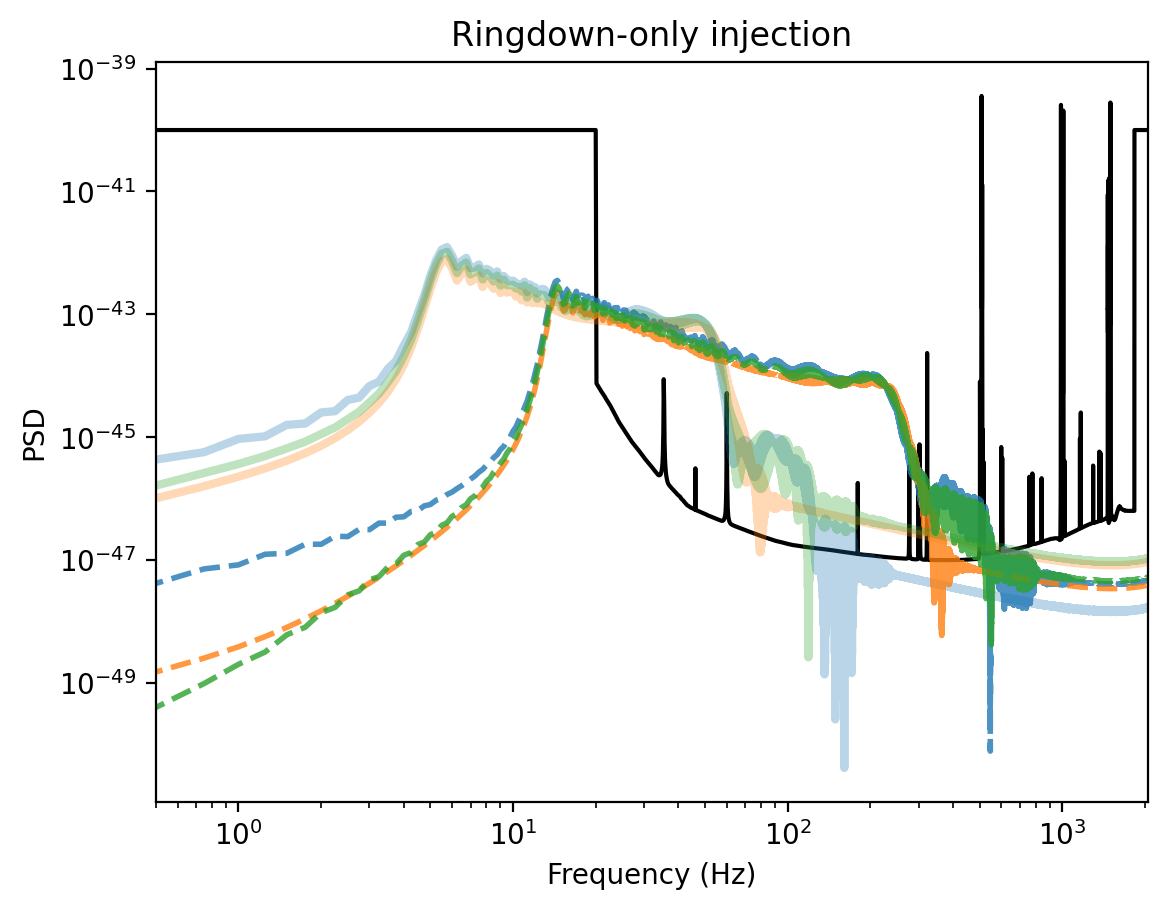

In [16]:
fig, ax = plt.subplots()
ax.loglog(fit.psds['H1'], color='k')
for inc in light_dfs_all.keys():
    dt = light_dfs_all[inc].index.values[1] - light_dfs_all[inc].index.values[0]

    h_freq_light = np.fft.rfft(light_dfs_all[inc].values)*dt
    fs_light = np.fft.rfftfreq(len(light_dfs_all[inc].index.values), d=dt)
    l, = ax.loglog(fs_light, 4*fs_light*np.abs(h_freq_light)**2, lw=2, ls='--', alpha=0.8)

    h_freq_heavy = np.fft.rfft(heavy_dfs_all[inc].values)*dt
    fs_heavy = np.fft.rfftfreq(len(heavy_dfs_all[inc].index.values), d=dt)
    ax.loglog(fs_heavy, 4*fs_heavy*np.abs(h_freq_heavy)**2, lw=3, color=l.get_color(), alpha=0.3)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.set_title('Ringdown-only injection')
ax.set_xlim(0.5, 2048)
# ax.legend(frameon=False)

/tmp/ipykernel_1445838/4132933991.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


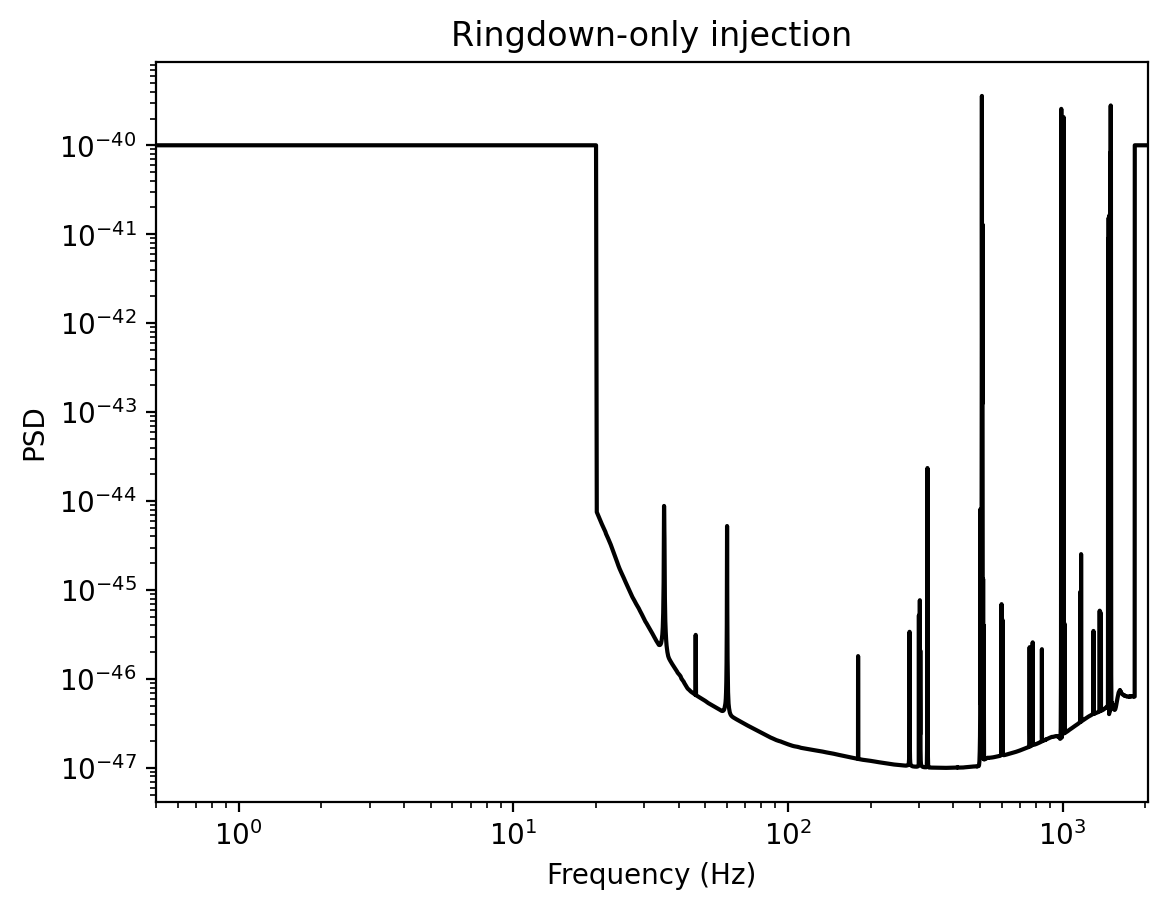

In [17]:
fig, ax = plt.subplots()
ax.loglog(fit.psds['H1'], color='k')
for inc in light_ana_all.keys():
    dt = 1/4096

    h_freq_light = np.fft.rfft(light_ana_all[inc].analysis_data['H1'].values)*dt
    fs_light = np.fft.rfftfreq(len(light_ana_all[inc].analysis_data['H1'].time.values), d=dt)
    l, = ax.loglog(fs_light, 4*fs_light*np.abs(h_freq_light)**2, lw=2, ls='--', alpha=0.8, label=inc)

    h_freq_heavy = np.fft.rfft(heavy_ana_all[inc].analysis_data['H1'].values)*dt
    fs_heavy = np.fft.rfftfreq(len(heavy_ana_all[inc].analysis_data['H1'].time.values), d=dt)
    ax.loglog(fs_heavy, 4*fs_heavy*np.abs(h_freq_heavy)**2, lw=3, color=l.get_color(), alpha=0.3)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("PSD")
ax.set_title('Ringdown-only injection')
ax.set_xlim(0.5, 2048)
ax.legend(frameon=False)

In [18]:
light_dfs_p_all = {inj.split('_')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(light_inj_p_all)}

# heavy_dfs_p = {inj.split('_')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(heavy_inj_p)}
heavy_dfs_p_all = {inj.split('_')[-2]: pd.read_hdf(inj, key=inj.split('_')[-1].split('.')[0]) for inj in sorted(heavy_inj_p_all)}

In [19]:
res_df = light_dfs['faceon'] - light_dfs['inclined']

(1126259462.397878, 1126259462.472878)

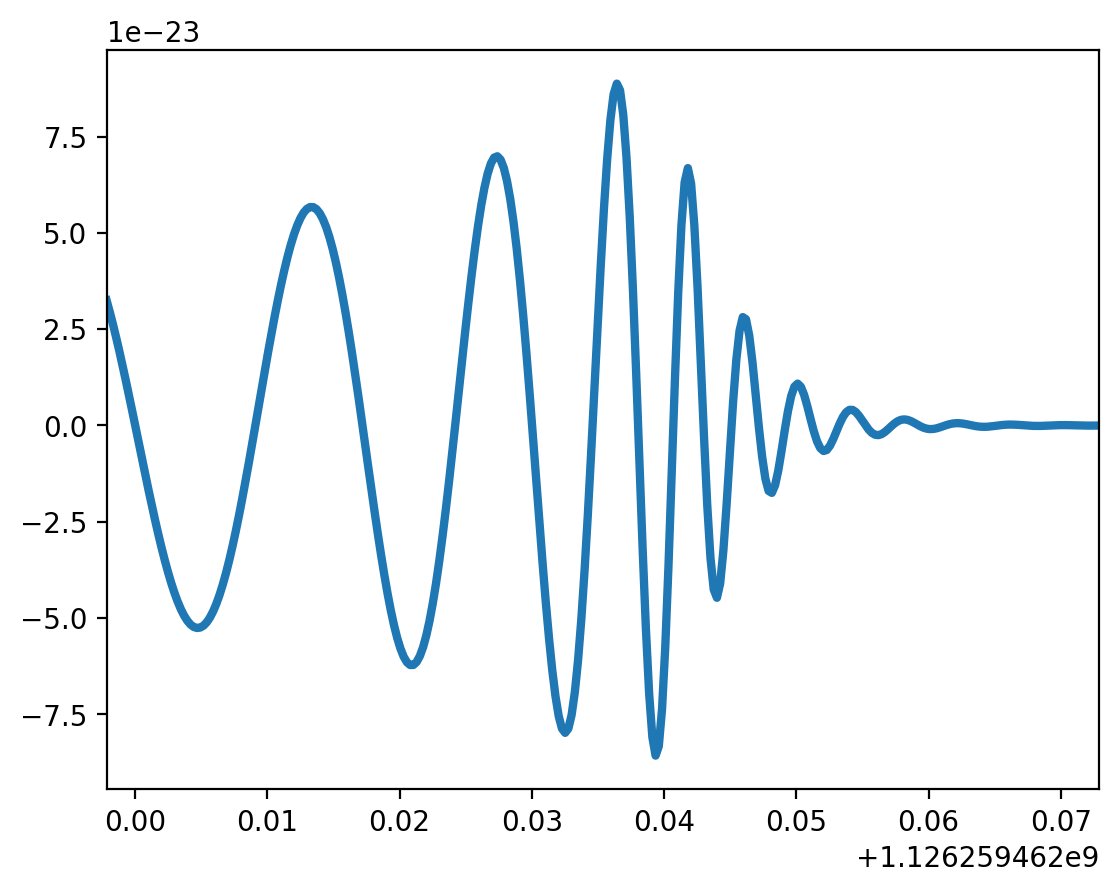

In [20]:
plt.plot(res_df, lw=3)
plt.xlim(np.median(res_df.index.values)-0.025, np.median(res_df.index.values)+0.05)

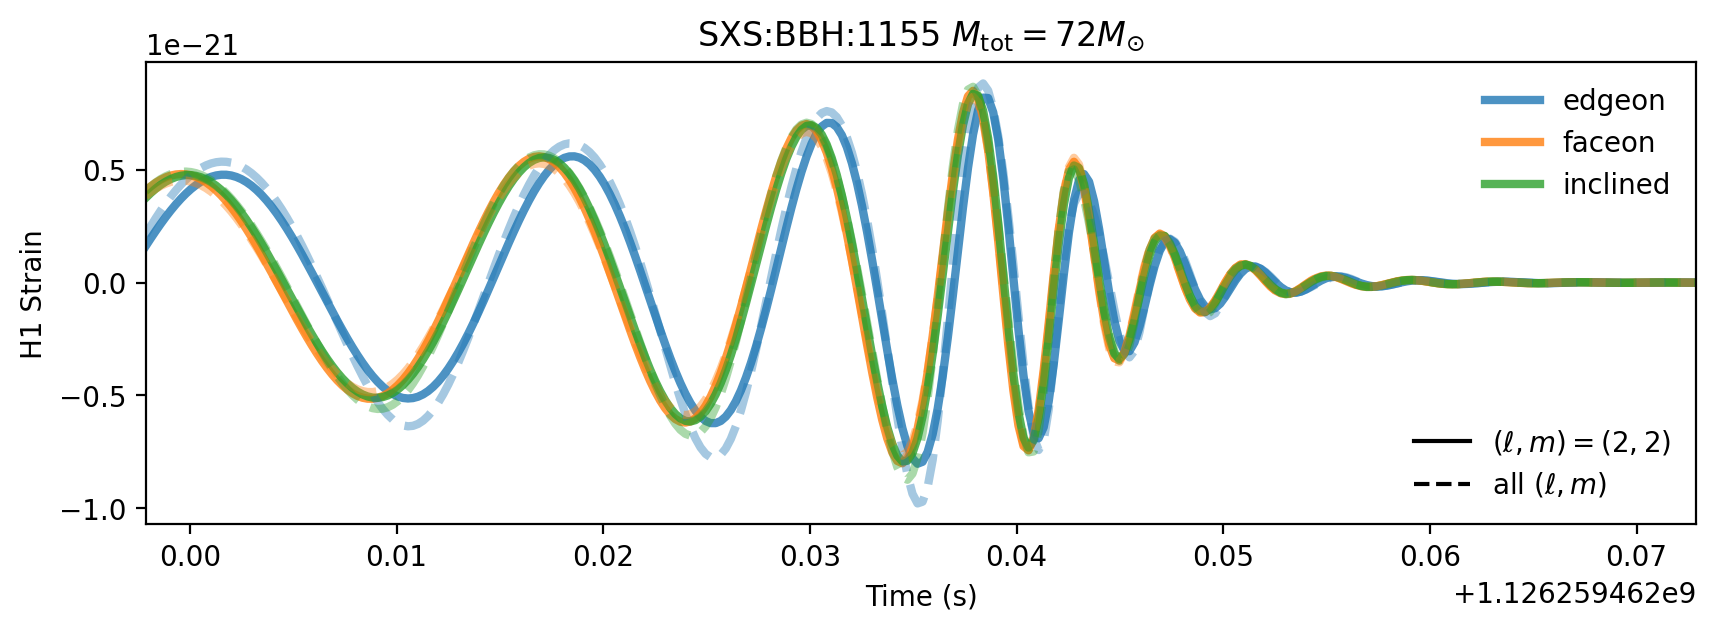

In [21]:
fig, ax = plt.subplots(figsize=(10, 3))
for i, (inc, df) in enumerate(light_dfs.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.8, label=inc)
for i, (inc, df) in enumerate(light_dfs_all.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.4, ls='--')

ax.set_xlim(np.median(df.index.values)-0.025, np.median(df.index.values)+0.05)
ax.set_xlabel('Time (s)')
ax.set_ylabel('H1 Strain')
ax.set_title('SXS:BBH:1155 $M_{\mathrm{tot}} = 72 M_{\odot}$')

leg1 = ax.legend(frameon=False)
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='k'), 
                  plt.Line2D([], [], color='k', ls='--')], 
                 ['$(\ell, m) = (2, 2)$',
                  'all $(\ell, m)$'], 
                 frameon=False, loc='lower right')

In [51]:
fit.start_times

{'H1': 1126259462.437694, 'L1': 1126259462.4307084}

(np.float64(1126259462.3228781),
 np.float64(1126259462.477878),
 np.float64(-8.47129792493806e-22),
 np.float64(9.040831988640244e-22))

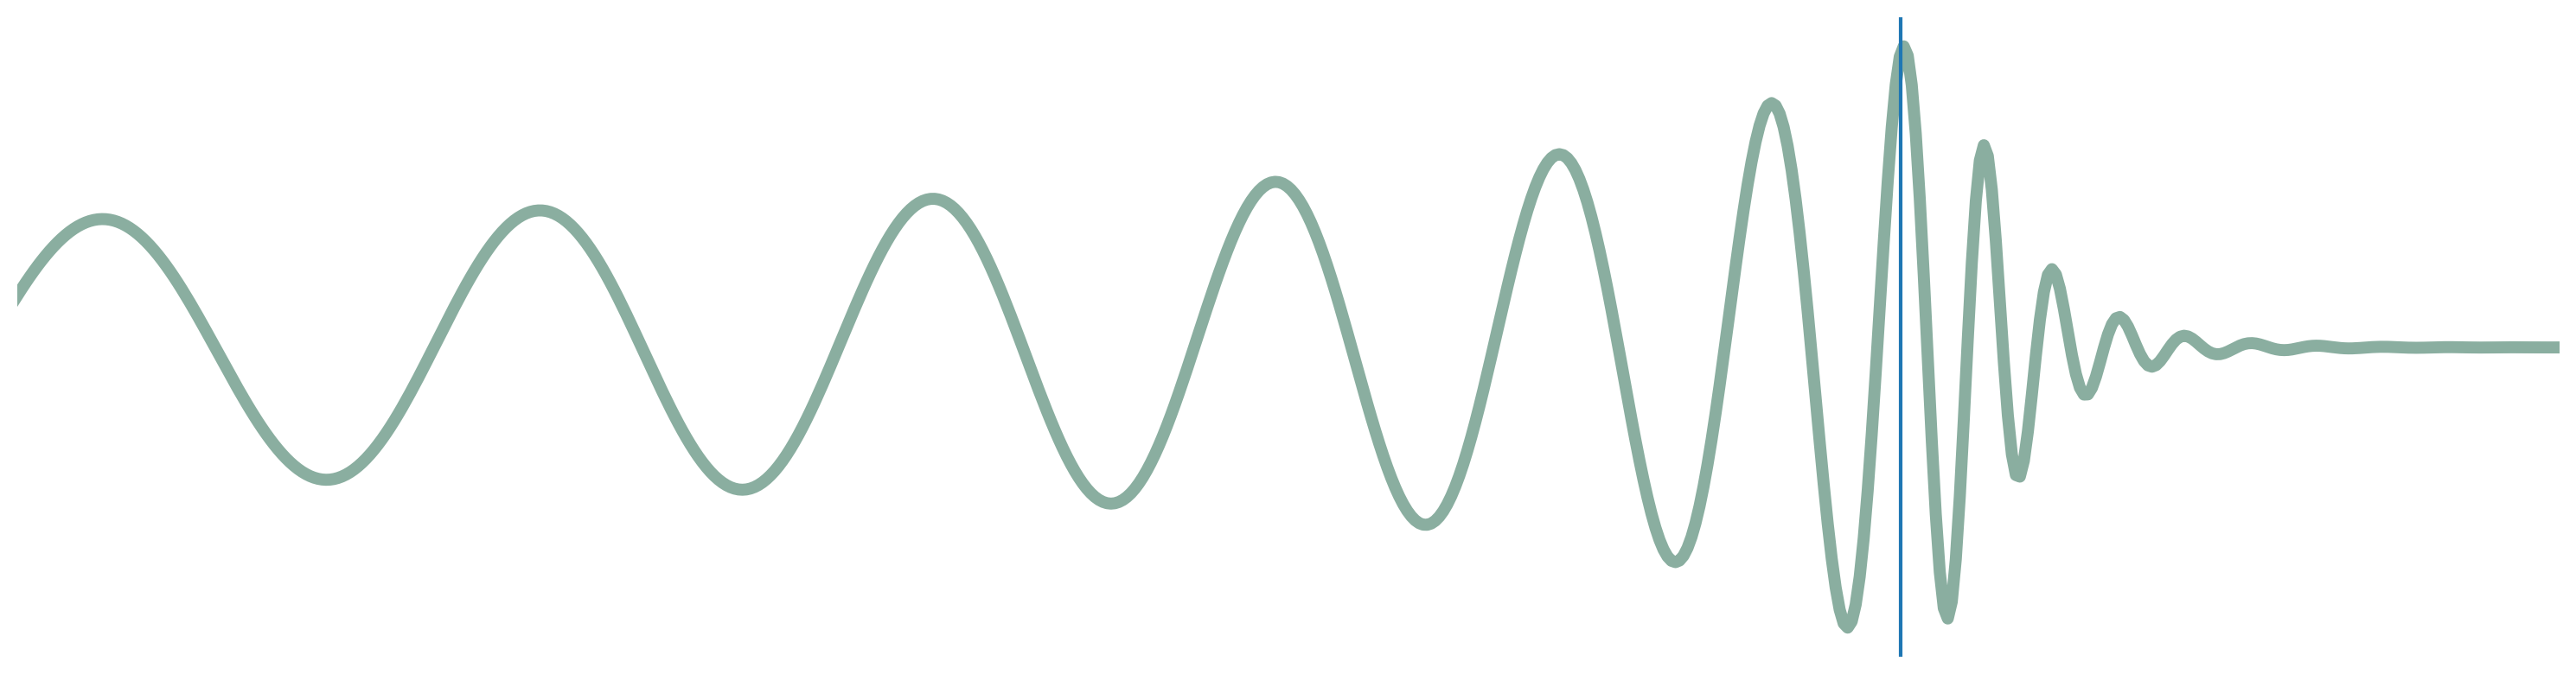

In [52]:
fig, ax = plt.subplots(figsize=(15, 4), layout='tight')
df = light_dfs_all['faceon']
ax.plot(df, lw=5, color='#6D9A88', alpha=0.8)

ax.set_xlim(np.median(df.index.values)-0.1, np.median(df.index.values)+0.055)
ax.axvline(1126259462.437694)
ax.axis('off')
# ax.set_xlabel('Time (s)')
# ax.set_ylabel('H1 Strain')
# ax.set_title('SXS:BBH:1155 $M_{\mathrm{tot}} = 72 M_{\odot}$')
# fig.savefig('/mnt/home/nkhusid/talks/oral_exam/imr_signal.png', bbox_inches='tight', dpi=300)

In [33]:
ax.axes

<Axes: >

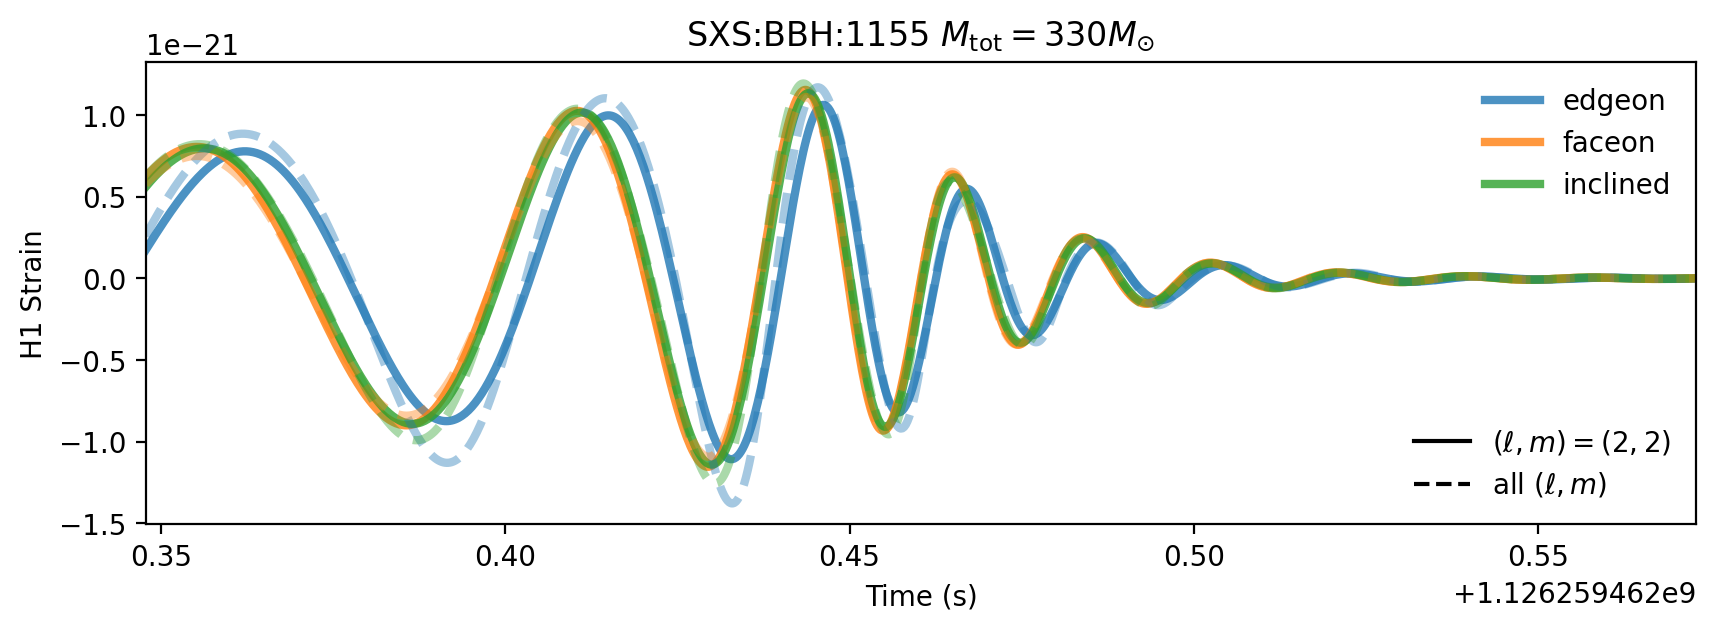

In [23]:
fig, ax = plt.subplots(figsize=(10, 3))
for i, (inc, df) in enumerate(heavy_dfs.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.8, label=inc)
for i, (inc, df) in enumerate(heavy_dfs_all.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.4, ls='--')

ax.set_xlim(np.median(df.index.values)-0.075, np.median(df.index.values)+0.15)
ax.set_xlabel('Time (s)')
ax.set_ylabel('H1 Strain')
ax.set_title('SXS:BBH:1155 $M_{\mathrm{tot}} = 330 M_{\odot}$')

leg1 = ax.legend(frameon=False)
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='k'), 
                  plt.Line2D([], [], color='k', ls='--')], 
                 ['$(\ell, m) = (2, 2)$',
                  'all $(\ell, m)$'], 
                 frameon=False, loc='lower right')

In [42]:
res.config['model']['m_max'] / 2, res.config['model']['m_min'] * 2

(321.237646115, 321.23764612)

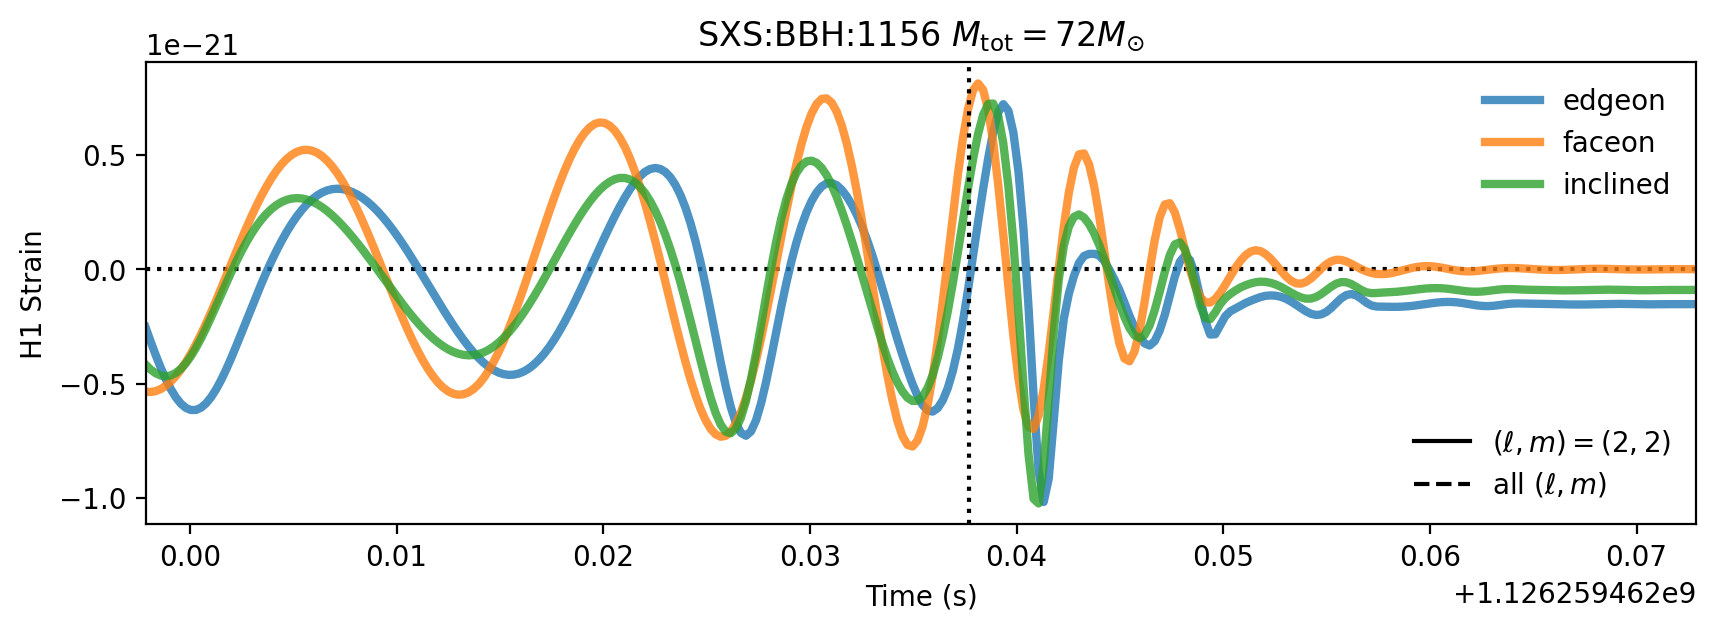

In [43]:
fig, ax = plt.subplots(figsize=(10, 3))
for i, (inc, df) in enumerate(light_dfs_p_all.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.8, label=inc)
# for i, (inc, df) in enumerate(heavy_dfs_p_all.items()):
#     ax.plot(df, color=f'C{i}', lw=3, alpha=0.4, ls='--')

ax.set_xlim(np.median(df.index.values)-0.2, np.median(df.index.values)+0.2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('H1 Strain')
ax.set_title('SXS:BBH:1156 $M_{\mathrm{tot}} = 72 M_{\odot}$')

leg1 = ax.legend(frameon=False)
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='k'), 
                  plt.Line2D([], [], color='k', ls='--')], 
                 ['$(\ell, m) = (2, 2)$',
                  'all $(\ell, m)$'], 
                 frameon=False, loc='lower right')

# mf = res_heavy.config['model']['m_max'] / 2
# TM = rd.qnms.T_MSUN * mf
ax.set_xlim(np.median(df.index.values)-0.025, np.median(df.index.values)+0.05)

ax.axhline(0, color='k', ls=':', zorder=-10)
ax.axvline(fit.start_times['H1'], color='k', ls=':')
# ax.axvspan(fit.start_times['H1'] - 12*TM, fit.start_times['H1'] + 12*TM, color='k', alpha=0.1, lw=0)

NameError: name 'res' is not defined

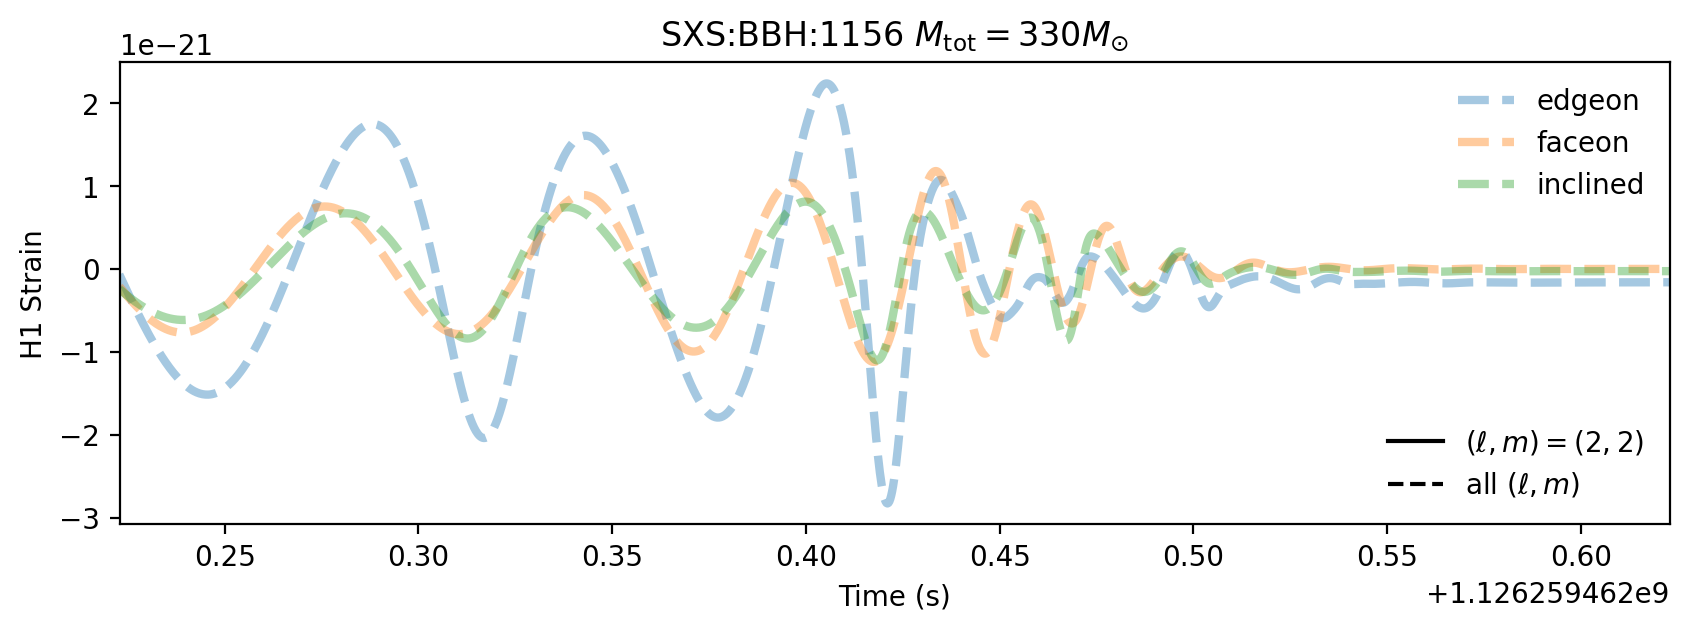

In [50]:
fig, ax = plt.subplots(figsize=(10, 3))
# for i, (inc, df) in enumerate(heavy_dfs_p.items()):
#     ax.plot(df, color=f'C{i}', lw=3, alpha=0.8, label=inc)
for i, (inc, df) in enumerate(heavy_dfs_p_all.items()):
    ax.plot(df, color=f'C{i}', lw=3, alpha=0.4, ls='--', label=inc)

ax.set_xlim(np.median(df.index.values)-0.2, np.median(df.index.values)+0.2)
ax.set_xlabel('Time (s)')
ax.set_ylabel('H1 Strain')
ax.set_title('SXS:BBH:1156 $M_{\mathrm{tot}} = 330 M_{\odot}$')

leg1 = ax.legend(frameon=False)
ax.add_artist(leg1)

leg2 = ax.legend([plt.Line2D([], [], color='k'), 
                  plt.Line2D([], [], color='k', ls='--')], 
                 ['$(\ell, m) = (2, 2)$',
                  'all $(\ell, m)$'], 
                 frameon=False, loc='lower right')

mf = res.config['model']['m_max'] / 2
TM = rd.qnms.T_MSUN * mf

ax.axhline(0, color='k', ls=':', zorder=-10)
ax.axvline(fit.start_times['H1'], color='k', ls=':')
ax.axvspan(fit.start_times['H1'] - 12*TM, fit.start_times['H1'] + 12*TM, color='k', alpha=0.1, lw=0)